In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


ModuleNotFoundError: No module named 'xgboost'

In [3]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
    --------------------------------------- 2.4/150.0 MB 13.4 MB/s eta 0:00:11
   - -------------------------------------- 5.5/150.0 MB 14.0 MB/s eta 0:00:11
   - -------------------------------------- 7.3/150.0 MB 12.6 MB/s eta 0:00:12
   -- ------------------------------------- 8.7/150.0 MB 10.5 MB/s eta 0:00:14
   -- ------------------------------------- 10.7/150.0 MB 10.5 MB/s eta 0:00:14
   --- ------------------------------------ 13.4/150.0 MB 10.8 MB/s eta 0:00:13
   ---- ----------------------------------- 15.2/150.0 MB 10.6 MB/s eta 0:00:13
   ---- ----------------------------------- 16.3/150.0 MB 10.2 MB/s eta 0:00:14
   ---- ----------------------------------- 18.1/150.0 MB 9.8 MB/s eta 0:00:14
   ----- ---------------------------------- 19.9/150.0 MB 9.6 MB/s eta 0:00:14
   ----- ---------------------------------- 22.0/150.0 MB 9.5 MB/s eta 0:00:14
   ------ --------------------------------- 24.6/150.0 M

In [4]:
!pip install xgboost


In [5]:
from xgboost import XGBRegressor


In [9]:
from xgboost import XGBRegressor


In [29]:
train = pd.read_csv(r"C:\Users\sande\Downloads\cltvdataset\train.csv")
test = pd.read_csv(r"C:\Users\sande\Downloads\cltvdataset\test.csv")


In [31]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


In [33]:
print(train.head())
print(train.columns)


   CustomerID  Customer.Lifetime.Value Coverage             Education  \
0        5917              7824.372789    Basic              Bachelor   
1        2057              8005.964669    Basic               College   
2        4119              8646.504109    Basic  High School or Below   
3        1801              9294.088719    Basic               College   
4        9618              5595.971365    Basic              Bachelor   

  EmploymentStatus Gender Income Location.Geo Location.Code Marital.Status  \
0       Unemployed      F      0    17.7,77.7         Urban        Married   
1         Employed      M  63357    28.8,76.6      Suburban        Married   
2         Employed      F  64125    21.6,88.4         Urban        Married   
3         Employed      M  67544      19,72.5      Suburban        Married   
4          Retired      F  19651    19.1,74.7      Suburban        Married   

   ...  Months.Since.Policy.Inception  Number.of.Open.Complaints  \
0  ...                  

In [35]:
X_train = train.drop(columns=["ltv"])  # Features only
y_train = train["ltv"]  # Target: lifetime value

X_test = test.copy()  # Features only for prediction


KeyError: "['ltv'] not found in axis"

In [37]:
print(train.columns.tolist())
train.head()


['CustomerID', 'Customer.Lifetime.Value', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location.Geo', 'Location.Code', 'Marital.Status', 'Monthly.Premium.Auto', 'Months.Since.Last.Claim', 'Months.Since.Policy.Inception', 'Number.of.Open.Complaints', 'Number.of.Policies', 'Policy.Type', 'Policy', 'Renew.Offer.Type', 'Sales.Channel', 'Total.Claim.Amount', 'Vehicle.Class', 'Vehicle.Size']


,CustomerID,Customer.Lifetime.Value,Coverage,Education,EmploymentStatus,Gender,Income,Location.Geo,Location.Code,Marital.Status,...,Months.Since.Policy.Inception,Number.of.Open.Complaints,Number.of.Policies,Policy.Type,Policy,Renew.Offer.Type,Sales.Channel,Total.Claim.Amount,Vehicle.Class,Vehicle.Size
0,5917,7824.372789,Basic,Bachelor,Unemployed,F,0,"17.7,77.7",Urban,Married,...,33,NaN,2.0,Personal Auto,Personal L2,Offer2,Branch,267.214383,Four-Door Car,2.0
1,2057,8005.964669,Basic,College,Employed,M,63357,"28.8,76.6",Suburban,Married,...,42,0.0,5.0,Personal Auto,Personal L2,Offer2,Agent,565.508572,SUV,2.0
2,4119,8646.504109,Basic,High School or Below,Employed,F,64125,"21.6,88.4",Urban,Married,...,44,0.0,3.0,Personal Auto,Personal L1,Offer2,Branch,369.818708,SUV,1.0
3,1801,9294.088719,Basic,College,Employed,M,67544,"19,72.5",Suburban,Married,...,15,NaN,3.0,Corporate Auto,Corporate L3,Offer1,Branch,556.800000,SUV,3.0
4,9618,5595.971365,Basic,Bachelor,Retired,F,19651,"19.1,74.7",Suburban,Married,...,68,0.0,5.0,Personal Auto,Personal L1,Offer2,Web,345.600000,Two-Door Car,3.0


In [41]:
print(train.columns.tolist())


['CustomerID', 'Customer.Lifetime.Value', 'Coverage', 'Education', 'EmploymentStatus', 'Gender', 'Income', 'Location.Geo', 'Location.Code', 'Marital.Status', 'Monthly.Premium.Auto', 'Months.Since.Last.Claim', 'Months.Since.Policy.Inception', 'Number.of.Open.Complaints', 'Number.of.Policies', 'Policy.Type', 'Policy', 'Renew.Offer.Type', 'Sales.Channel', 'Total.Claim.Amount', 'Vehicle.Class', 'Vehicle.Size']


In [43]:
# Clean column names
train.columns = train.columns.str.strip().str.lower().str.replace(' ', '_')
test.columns = test.columns.str.strip().str.lower().str.replace(' ', '_')

print(train.columns.tolist())


['customerid', 'customer.lifetime.value', 'coverage', 'education', 'employmentstatus', 'gender', 'income', 'location.geo', 'location.code', 'marital.status', 'monthly.premium.auto', 'months.since.last.claim', 'months.since.policy.inception', 'number.of.open.complaints', 'number.of.policies', 'policy.type', 'policy', 'renew.offer.type', 'sales.channel', 'total.claim.amount', 'vehicle.class', 'vehicle.size']


In [47]:
X_train = train.drop(columns=["customer.lifetime.value"])
y_train = train["customer.lifetime.value"]

X_test = test.copy()


In [49]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:coverage: object, education: object, employmentstatus: object, gender: object, income: object, location.geo: object, location.code: object, marital.status: object, policy.type: object, policy: object, renew.offer.type: object, sales.channel: object, vehicle.class: object

In [52]:
print(X_train.dtypes)


customerid                         int64
coverage                          object
education                         object
employmentstatus                  object
gender                            object
income                            object
location.geo                      object
location.code                     object
marital.status                    object
monthly.premium.auto             float64
months.since.last.claim            int64
months.since.policy.inception      int64
number.of.open.complaints        float64
number.of.policies               float64
policy.type                       object
policy                            object
renew.offer.type                  object
sales.channel                     object
total.claim.amount               float64
vehicle.class                     object
vehicle.size                     float64
dtype: object


In [54]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align columns in test set to match train set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


In [63]:
X_test["predicted_ltv"] = predictions
X_test["segment"] = pd.qcut(X_test["predicted_ltv"], q=4, labels=["Low", "Mid", "High", "Top"])

X_test[["customer_id", "predicted_ltv", "segment"]].to_csv("ltv_predictions.csv", index=False)


KeyError: "['customer_id'] not in index"

In [65]:
X_test["predicted_ltv"] = predictions
X_test["segment"] = pd.qcut(X_test["predicted_ltv"], q=4, labels=["Low", "Mid", "High", "Top"])

X_test[["customerid", "predicted_ltv", "segment"]].to_csv("ltv_predictions.csv", index=False)


In [68]:
pd.DataFrame({"predicted_ltv": predictions}).to_csv("ltv_predictions.csv", index=False)


<Figure size 1000x600 with 0 Axes>

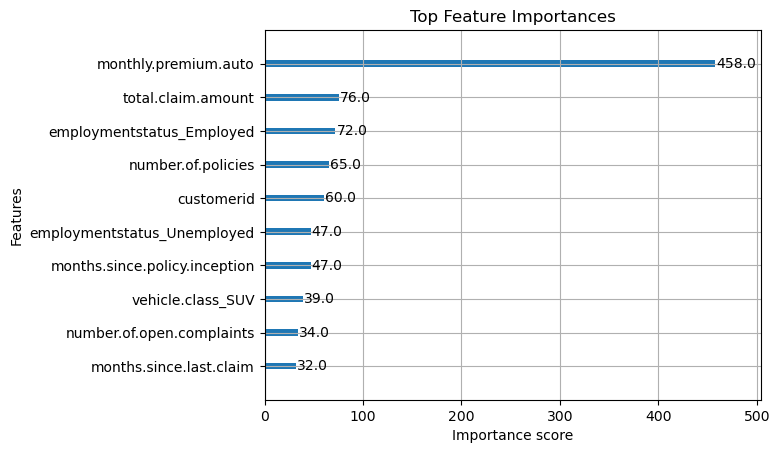

In [70]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=10)  # Top 10 features
plt.title("Top Feature Importances")
plt.show()


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# If you have actual test targets
# y_test = test["ltv"]
# mae = mean_absolute_error(y_test, predictions)
# rmse = np.sqrt(mean_squared_error(y_test, predictions))

# print("MAE:", mae)
# print("RMSE:", rmse)


In [78]:
import joblib

joblib.dump(model, "xgb_ltv_model.pkl")  # Save model


['xgb_ltv_model.pkl']

In [80]:
model = joblib.load("xgb_ltv_model.pkl")


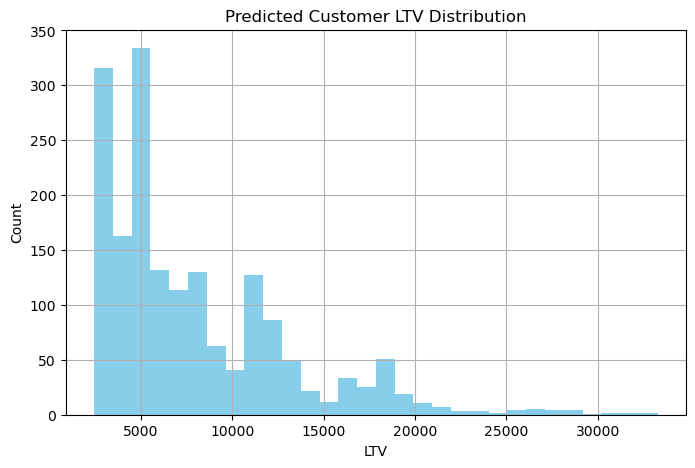

In [82]:
plt.figure(figsize=(8,5))
plt.hist(predictions, bins=30, color='skyblue')
plt.title("Predicted Customer LTV Distribution")
plt.xlabel("LTV")
plt.ylabel("Count")
plt.grid(True)
plt.show()


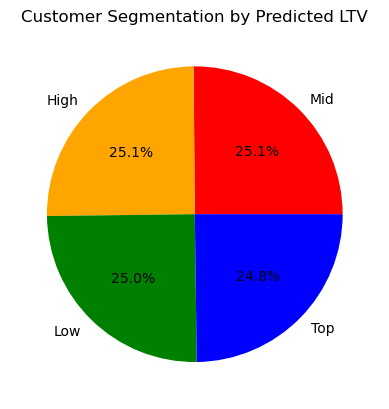

In [84]:
X_test["segment"].value_counts().plot.pie(autopct='%1.1f%%', colors=['red', 'orange', 'green', 'blue'])
plt.title("Customer Segmentation by Predicted LTV")
plt.ylabel("")
plt.show()


In [88]:
train.head()
train.columns


Index(['customerid', 'customer.lifetime.value', 'coverage', 'education',
       'employmentstatus', 'gender', 'income', 'location.geo', 'location.code',
       'marital.status', 'monthly.premium.auto', 'months.since.last.claim',
       'months.since.policy.inception', 'number.of.open.complaints',
       'number.of.policies', 'policy.type', 'policy', 'renew.offer.type',
       'sales.channel', 'total.claim.amount', 'vehicle.class', 'vehicle.size'],
      dtype='object')